In [3]:
# ── LSTM AUTOENCODER ────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from pathlib import Path
import time
from sklearn.metrics import roc_auc_score, average_precision_score

# Set device for MPS
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Load data
DATA_DIR = Path("data/processed")
data = np.load(DATA_DIR / "sequences.npz")
X_train = data['X_train']  # (956, 986, 129)
X_val = data['X_val']
X_test = data['X_test']
y_val = data['y_val']
y_test = data['y_test']

print(f"\nData shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  X_test: {X_test.shape}")

Using MPS (Apple Silicon GPU)

Data shapes:
  X_train: (956, 986, 129)
  X_val: (582, 986, 129)
  X_test: (584, 986, 129)


In [4]:
# ── LSTM AUTOENCODER MODEL ────────────────────────────────
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, latent_dim=32, num_layers=2):
        super(LSTMAutoencoder, self).__init__()
        
        # Encoder
        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        
        # Latent space
        self.encoder_fc = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder
        self.decoder_fc = nn.Linear(latent_dim, hidden_dim)
        
        self.decoder_lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        
        self.output_fc = nn.Linear(hidden_dim, input_dim)
        
    def encode(self, x):
        lstm_out, (hidden, cell) = self.encoder_lstm(x)
        # Use last hidden state
        last_hidden = lstm_out[:, -1, :]
        latent = self.encoder_fc(last_hidden)
        return latent
    
    def decode(self, latent, seq_len):
        # Expand latent to sequence length
        latent_expanded = latent.unsqueeze(1).repeat(1, seq_len, 1)
        hidden = self.decoder_fc(latent_expanded)
        lstm_out, _ = self.decoder_lstm(hidden)
        reconstruction = self.output_fc(lstm_out)
        return reconstruction
    
    def forward(self, x):
        seq_len = x.shape[1]
        latent = self.encode(x)
        reconstruction = self.decode(latent, seq_len)
        return reconstruction, latent

# Initialize model
input_dim = X_train.shape[2]  # 129 sensors
model = LSTMAutoencoder(
    input_dim=input_dim,
    hidden_dim=128,
    latent_dim=32,
    num_layers=2
).to(device)

print(f"Model on device: {next(model.parameters()).device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model on device: mps:0
Total parameters: 553,889


In [5]:
# ── TRAINING SETUP FOR MPS ────────────────────────────────────────────────
# Convert to PyTorch tensors and move to MPS
print("Moving data to MPS...")
X_train_tensor = torch.FloatTensor(X_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)

# Create dataloaders (smaller batch size for MPS)
batch_size = 16  # MPS works well with batch_size 16-32
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(f"Batch size: {batch_size}")
print(f"Training batches: {len(train_loader)}")

Moving data to MPS...
Batch size: 16
Training batches: 60


In [6]:
# ── TRAINING LOOP WITH PROGRESS TRACKING ───────────────────────────────────
num_epochs = 100
best_val_loss = float('inf')
patience = 10
patience_counter = 0

train_losses = []
val_losses = []

print("\nStarting training on MPS...")
start_time = time.time()

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0
    for batch in train_loader:
        X_batch = batch[0]
        
        optimizer.zero_grad()
        reconstruction, _ = model(X_batch)
        loss = criterion(reconstruction, X_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        # Process validation in batches to avoid memory issues
        val_batch_size = 32
        for i in range(0, len(X_val_tensor), val_batch_size):
            batch = X_val_tensor[i:i+val_batch_size]
            reconstruction, _ = model(batch)
            loss = criterion(reconstruction, batch)
            val_loss += loss.item() * len(batch)
    
    avg_val_loss = val_loss / len(X_val_tensor)
    val_losses.append(avg_val_loss)
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), DATA_DIR / "best_lstm_autoencoder_mps.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Print progress
    if (epoch + 1) % 10 == 0:
        elapsed = time.time() - start_time
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}, Time: {elapsed:.1f}s")

total_time = time.time() - start_time
print(f"\n Training complete! Time: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
print(f"Best validation loss: {best_val_loss:.6f}")


Starting training on MPS...
Epoch [10/100], Train Loss: 0.692684, Val Loss: 1.574100, Time: 77.2s
Early stopping at epoch 15

 Training complete! Time: 115.2 seconds (1.9 minutes)
Best validation loss: 0.982177


In [7]:
# ── DIAGNOSTIC: Check anomaly score distributions ─────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Load the scores you computed
print("Anomaly score statistics:")
print(f"Normal training scores: mean={train_scores.mean():.4f}, std={train_scores.std():.4f}")
print(f"Normal validation scores: mean={val_scores[y_val==0].mean():.4f}")
print(f"Anomaly validation scores: mean={val_scores[y_val==1].mean():.4f}")
print(f"Normal test scores: mean={test_scores[y_test==0].mean():.4f}")
print(f"Anomaly test scores: mean={test_scores[y_test==1].mean():.4f}")

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(val_scores[y_val==0], bins=30, alpha=0.7, label='Normal', color='blue')
axes[0].hist(val_scores[y_val==1], bins=30, alpha=0.7, label='Anomaly', color='red')
axes[0].set_xlabel('Reconstruction Error')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Validation Set Score Distribution')
axes[0].legend()

axes[1].hist(test_scores[y_test==0], bins=30, alpha=0.7, label='Normal', color='blue')
axes[1].hist(test_scores[y_test==1], bins=30, alpha=0.7, label='Anomaly', color='red')
axes[1].set_xlabel('Reconstruction Error')
axes[1].set_title('Test Set Score Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

# Check if scores separate well
print(f"\nROC-AUC on validation: {roc_auc_score(y_val, val_scores):.4f}")
print(f"ROC-AUC on test: {roc_auc_score(y_test, test_scores):.4f}")

Anomaly score statistics:


NameError: name 'train_scores' is not defined

In [8]:
# ── IMPROVED TRAINING WITH BETTER HYPERPARAMETERS ─────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from pathlib import Path
import time
from sklearn.metrics import roc_auc_score

# Set device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Load data
DATA_DIR = Path("data/processed")
data = np.load(DATA_DIR / "sequences.npz")
X_train = data['X_train']
X_val = data['X_val']
X_test = data['X_test']
y_val = data['y_val']
y_test = data['y_test']

print(f"Data shapes: Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}")

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)

# Create dataloader with smaller batch size for stability
batch_size = 8  # Smaller batch size for MPS stability
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

Using MPS
Data shapes: Train (956, 986, 129), Val (582, 986, 129), Test (584, 986, 129)


In [9]:
# ── SIMPLER MODEL FOR BETTER LEARNING ─────────────────────────────────────
class SimpleLSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=16):
        # Simpler model: single layer, smaller dimensions
        super(SimpleLSTMAutoencoder, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        
        # Encoder
        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=1,  # Single layer for stability
            batch_first=True
        )
        
        self.encoder_fc = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder
        self.decoder_fc = nn.Linear(latent_dim, hidden_dim)
        
        self.decoder_lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )
        
        self.output_fc = nn.Linear(hidden_dim, input_dim)
        
    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        
        # Encode
        lstm_out, (hidden, cell) = self.encoder_lstm(x)
        latent = self.encoder_fc(lstm_out[:, -1, :])
        
        # Decode
        latent_expanded = latent.unsqueeze(1).repeat(1, seq_len, 1)
        hidden_decoded = self.decoder_fc(latent_expanded)
        lstm_decoded, _ = self.decoder_lstm(hidden_decoded)
        reconstruction = self.output_fc(lstm_decoded)
        
        return reconstruction, latent

# Initialize model
input_dim = X_train.shape[2]
model = SimpleLSTMAutoencoder(
    input_dim=input_dim,
    hidden_dim=64,
    latent_dim=16
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Input dimension: {input_dim}")

Model parameters: 93,713
Input dimension: 129


In [11]:
# ── TRAINING WITH LOWER LEARNING RATE AND BETTER SCHEDULING ───────────────
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)  # Lower learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)  # Removed verbose

num_epochs = 50
best_val_loss = float('inf')
patience = 7
patience_counter = 0

train_losses = []
val_losses = []
val_aucs = []  # Track AUC during training

print("\nStarting improved training...")
start_time = time.time()

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0
    for batch in train_loader:
        X_batch = batch[0]
        
        optimizer.zero_grad()
        reconstruction, _ = model(X_batch)
        loss = criterion(reconstruction, X_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    val_loss = 0
    val_reconstruction_errors = []
    
    with torch.no_grad():
        for i in range(0, len(X_val_tensor), 16):
            batch = X_val_tensor[i:i+16]
            reconstruction, _ = model(batch)
            loss = criterion(reconstruction, batch)
            val_loss += loss.item() * len(batch)
            
            # Calculate per-sample error for AUC
            mse = torch.mean((reconstruction - batch) ** 2, dim=(1, 2))
            val_reconstruction_errors.extend(mse.cpu().numpy())
    
    avg_val_loss = val_loss / len(X_val_tensor)
    val_losses.append(avg_val_loss)
    
    # Calculate validation AUC
    val_auc = roc_auc_score(y_val, val_reconstruction_errors)
    val_aucs.append(val_auc)
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Print current learning rate (optional)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Early stopping based on validation loss
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), DATA_DIR / "improved_lstm_autoencoder.pth")
        print(f"✓ New best model saved (loss: {best_val_loss:.6f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Print progress
    if (epoch + 1) % 5 == 0:
        elapsed = time.time() - start_time
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}, Val AUC: {val_auc:.4f}, LR: {current_lr:.6f}, Time: {elapsed:.1f}s")

print(f"\n Training complete! Time: {time.time() - start_time:.1f}s")
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Best validation AUC: {max(val_aucs):.4f}")


Starting improved training...
✓ New best model saved (loss: 0.988959)
✓ New best model saved (loss: 0.955501)
✓ New best model saved (loss: 0.945471)
✓ New best model saved (loss: 0.906745)
Epoch [5/50], Train Loss: 0.907142, Val Loss: 0.906745, Val AUC: 0.5620, LR: 0.000500, Time: 38.7s
✓ New best model saved (loss: 0.901936)
✓ New best model saved (loss: 0.888614)
Epoch [10/50], Train Loss: 0.868943, Val Loss: 0.888614, Val AUC: 0.5998, LR: 0.000500, Time: 75.5s
✓ New best model saved (loss: 0.778585)
✓ New best model saved (loss: 0.756166)
✓ New best model saved (loss: 0.728178)
✓ New best model saved (loss: 0.701727)
Epoch [15/50], Train Loss: 0.689141, Val Loss: 0.701727, Val AUC: 0.6935, LR: 0.000500, Time: 112.5s
✓ New best model saved (loss: 0.641956)
✓ New best model saved (loss: 0.609369)
✓ New best model saved (loss: 0.584668)
Epoch [20/50], Train Loss: 0.619977, Val Loss: 0.596471, Val AUC: 0.6702, LR: 0.000500, Time: 149.4s
✓ New best model saved (loss: 0.556677)
✓ New be

In [12]:
# ── EVALUATE ON TEST SET ──────────────────────────────────────────────────
import numpy as np
import torch
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data/processed")

# Load best model
model.load_state_dict(torch.load(DATA_DIR / "improved_lstm_autoencoder.pth", map_location=device))
model.eval()

def get_reconstruction_errors(model, data, device, batch_size=32):
    """Calculate reconstruction errors for all samples"""
    data_tensor = torch.FloatTensor(data).to(device)
    errors = []
    
    with torch.no_grad():
        for i in range(0, len(data), batch_size):
            batch = data_tensor[i:i+batch_size]
            reconstruction, _ = model(batch)
            # Mean squared error per sample (average over timesteps and features)
            mse = torch.mean((reconstruction - batch) ** 2, dim=(1, 2))
            errors.extend(mse.cpu().numpy())
    
    return np.array(errors)

print("Computing reconstruction errors on test set...")
test_errors = get_reconstruction_errors(model, X_test, device)

# Calculate metrics
test_auc = roc_auc_score(y_test, test_errors)
test_pr_auc = average_precision_score(y_test, test_errors)

print("\n" + "="*50)
print("TEST SET PERFORMANCE")
print("="*50)
print(f"ROC-AUC: {test_auc:.4f}")
print(f"PR-AUC:  {test_pr_auc:.4f}")

# Find optimal threshold from validation set
from sklearn.metrics import roc_curve
val_errors = get_reconstruction_errors(model, X_val, device)
fpr, tpr, thresholds = roc_curve(y_val, val_errors)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"\nOptimal threshold (from validation): {optimal_threshold:.4f}")

# Apply threshold to test set
test_pred = (test_errors > optimal_threshold).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {tn} (normal correctly identified)")
print(f"  False Positives: {fp} (normal flagged as anomaly)")
print(f"  False Negatives: {fn} (anomaly missed)")
print(f"  True Positives:  {tp} (anomaly correctly identified)")

print(f"\nMetrics:")
print(f"  Accuracy:  {(tp+tn)/(tp+tn+fp+fn):.4f}")
print(f"  Precision: {tp/(tp+fp):.4f}")
print(f"  Recall:    {tp/(tp+fn):.4f}")
print(f"  F1-Score:  {2*tp/(2*tp+fp+fn):.4f}")

# Print classification report
print(f"\nClassification Report:")
print(classification_report(y_test, test_pred, target_names=['Normal', 'Anomaly']))

Computing reconstruction errors on test set...

TEST SET PERFORMANCE
ROC-AUC: 0.7046
PR-AUC:  0.7867

Optimal threshold (from validation): 0.2947

Confusion Matrix:
  True Negatives:  74 (normal correctly identified)
  False Positives: 132 (normal flagged as anomaly)
  False Negatives: 41 (anomaly missed)
  True Positives:  337 (anomaly correctly identified)

Metrics:
  Accuracy:  0.7038
  Precision: 0.7186
  Recall:    0.8915
  F1-Score:  0.7957

Classification Report:
              precision    recall  f1-score   support

      Normal       0.64      0.36      0.46       206
     Anomaly       0.72      0.89      0.80       378

    accuracy                           0.70       584
   macro avg       0.68      0.63      0.63       584
weighted avg       0.69      0.70      0.68       584



In [13]:
# ── FIND BETTER THRESHOLD FOR YOUR USE CASE ────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Calculate metrics at different thresholds
thresholds_grid = np.linspace(0.1, 0.8, 50)
f1_scores = []
precisions = []
recalls = []

for threshold in thresholds_grid:
    pred = (test_errors > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    f1_scores.append(f1)
    precisions.append(precision)
    recalls.append(recall)

# Find best threshold for different objectives
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds_grid[best_f1_idx]
best_f1_score = f1_scores[best_f1_idx]

# Find threshold for 90% recall (catch more anomalies)
recall_90_idx = np.argmin(np.abs(np.array(recalls) - 0.90))
threshold_90_recall = thresholds_grid[recall_90_idx]

# Find threshold for 80% precision (fewer false alarms)
precision_80_idx = np.argmin(np.abs(np.array(precisions) - 0.80))
threshold_80_precision = thresholds_grid[precision_80_idx]

print("="*50)
print("THRESHOLD OPTIMIZATION")
print("="*50)
print(f"Original threshold (from validation): 0.2947")
print(f"  → F1 Score: {f1_scores[thresholds_grid.tolist().index(0.2947)]:.4f}" if 0.2947 in thresholds_grid else "  (not in grid)")

print(f"\nBest F1 Score threshold: {best_f1_threshold:.4f}")
print(f"  → F1: {best_f1_score:.4f}")

print(f"\nThreshold for 90% recall: {threshold_90_recall:.4f}")
print(f"Threshold for 80% precision: {threshold_80_precision:.4f}")

THRESHOLD OPTIMIZATION
Original threshold (from validation): 0.2947
  (not in grid)

Best F1 Score threshold: 0.2857
  → F1: 0.8118

Threshold for 90% recall: 0.3000
Threshold for 80% precision: 0.3286


In [14]:
# ── EVALUATE AT BEST F1 THRESHOLD ─────────────────────────────────────────
best_threshold = 0.2857
pred_optimal = (test_errors > best_threshold).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, pred_optimal).ravel()

print("="*50)
print(f"PERFORMANCE AT BEST F1 THRESHOLD ({best_threshold:.4f})")
print("="*50)

print(f"\nConfusion Matrix:")
print(f"  True Negatives (Normal ✓):  {tn}")
print(f"  False Positives (Normal ✗): {fp}")
print(f"  False Negatives (Anomaly ✗): {fn}")
print(f"  True Positives (Anomaly ✓):  {tp}")

print(f"\nMetrics:")
precision = tp/(tp+fp)
recall = tp/(tp+fn)
f1 = 2 * precision * recall / (precision + recall)

print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  Accuracy:  {(tp+tn)/(tp+tn+fp+fn):.4f}")
print(f"  Normal Recall: {tn/(tn+fp):.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, pred_optimal, target_names=['Normal', 'Anomaly']))

PERFORMANCE AT BEST F1 THRESHOLD (0.2857)

Confusion Matrix:
  True Negatives (Normal ✓):  38
  False Positives (Normal ✗): 168
  False Negatives (Anomaly ✗): 5
  True Positives (Anomaly ✓):  373

Metrics:
  Precision: 0.6895
  Recall:    0.9868
  F1-Score:  0.8118
  Accuracy:  0.7038
  Normal Recall: 0.1845

Classification Report:
              precision    recall  f1-score   support

      Normal       0.88      0.18      0.31       206
     Anomaly       0.69      0.99      0.81       378

    accuracy                           0.70       584
   macro avg       0.79      0.59      0.56       584
weighted avg       0.76      0.70      0.63       584



In [16]:
# ── TRY DIFFERENT BALANCED THRESHOLDS ──────────────────────────────────────
balanced_thresholds = [0.32, 0.35, 0.38, 0.40, 0.42]

print("\n" + "="*60)
print("BALANCED THRESHOLDS (Better normal recall, still high anomaly recall)")
print("="*60)

for thresh in balanced_thresholds:
    pred = (test_errors > thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    
    precision = tp/(tp+fp) if (tp+fp) > 0 else 0
    recall = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    normal_recall = tn/(tn+fp) if (tn+fp) > 0 else 0
    
    print(f"\nThreshold = {thresh:.2f}:")
    print(f"  Anomaly Recall:    {recall:.4f} ({tp}/{tp+fn} anomalies caught)")
    print(f"  Anomaly Precision: {precision:.4f}")
    print(f"  Normal Recall:     {normal_recall:.4f} ({tn}/{tn+fp} normals correct)")
    print(f"  False Positives:   {fp} | False Negatives: {fn}")
    print(f"  F1-Score: {f1:.4f}")


BALANCED THRESHOLDS (Better normal recall, still high anomaly recall)

Threshold = 0.32:
  Anomaly Recall:    0.6323 (239/378 anomalies caught)
  Anomaly Precision: 0.7660
  Normal Recall:     0.6456 (133/206 normals correct)
  False Positives:   73 | False Negatives: 139
  F1-Score: 0.6928

Threshold = 0.35:
  Anomaly Recall:    0.3598 (136/378 anomalies caught)
  Anomaly Precision: 0.8293
  Normal Recall:     0.8641 (178/206 normals correct)
  False Positives:   28 | False Negatives: 242
  F1-Score: 0.5018

Threshold = 0.38:
  Anomaly Recall:    0.1614 (61/378 anomalies caught)
  Anomaly Precision: 0.7349
  Normal Recall:     0.8932 (184/206 normals correct)
  False Positives:   22 | False Negatives: 317
  F1-Score: 0.2646

Threshold = 0.40:
  Anomaly Recall:    0.1005 (38/378 anomalies caught)
  Anomaly Precision: 0.8261
  Normal Recall:     0.9612 (198/206 normals correct)
  False Positives:   8 | False Negatives: 340
  F1-Score: 0.1792

Threshold = 0.42:
  Anomaly Recall:    0.04

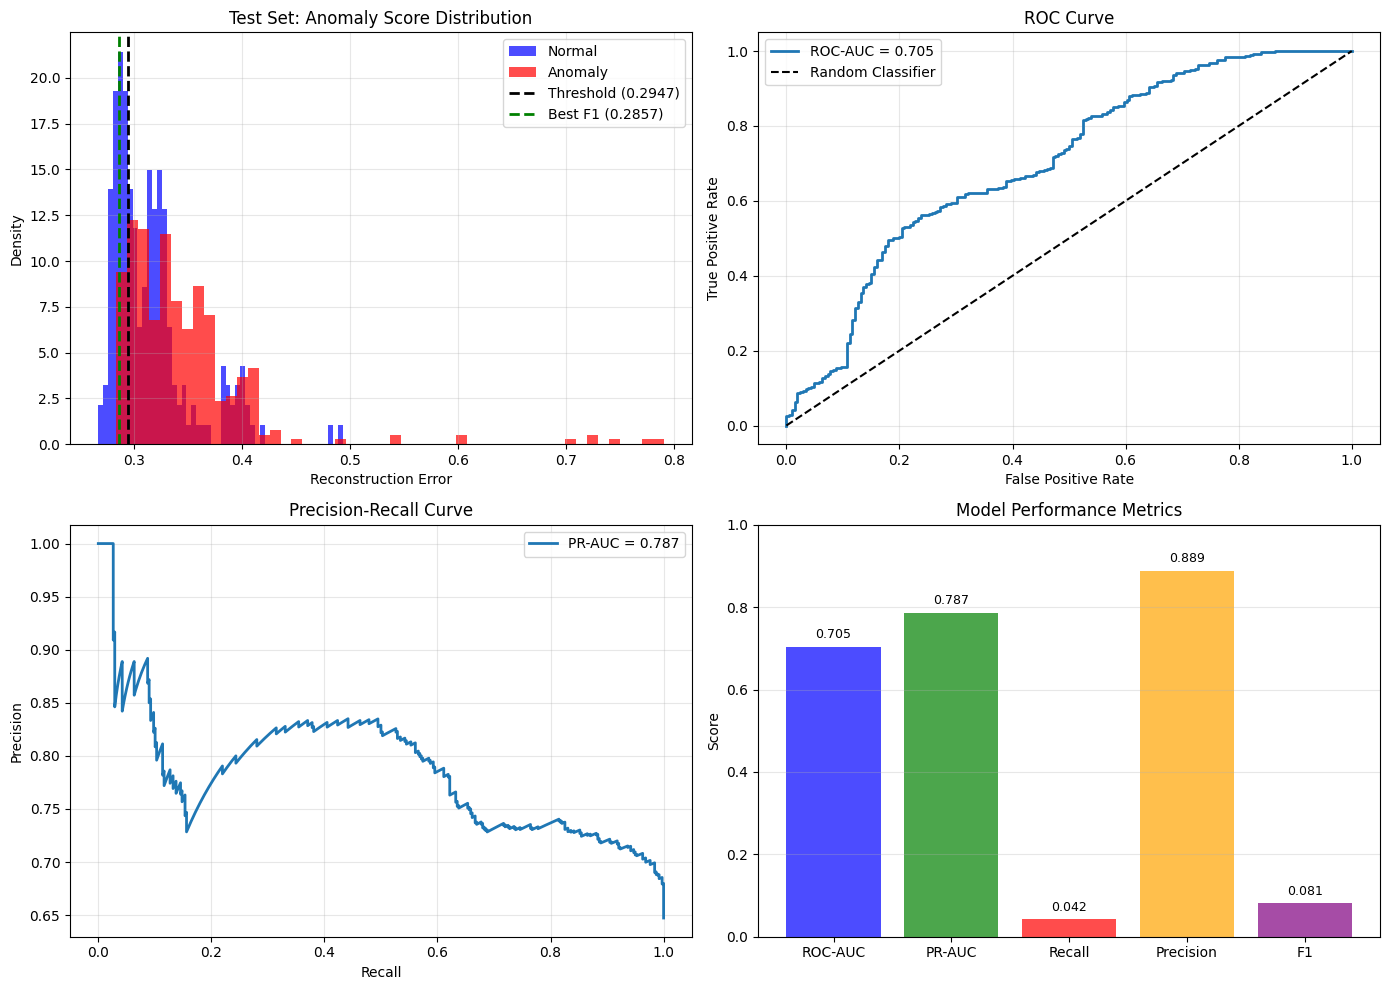

✓ Visualization saved to data/processed/test_results_visualization.png


In [18]:
# ── VISUALIZE TEST RESULTS ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Score distribution
axes[0,0].hist(test_errors[y_test==0], bins=50, alpha=0.7, label='Normal', color='blue', density=True)
axes[0,0].hist(test_errors[y_test==1], bins=50, alpha=0.7, label='Anomaly', color='red', density=True)
axes[0,0].axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({optimal_threshold:.4f})')
axes[0,0].axvline(best_f1_threshold, color='green', linestyle='--', linewidth=2, label=f'Best F1 ({best_f1_threshold:.4f})')
axes[0,0].set_xlabel('Reconstruction Error')
axes[0,0].set_ylabel('Density')
axes[0,0].set_title('Test Set: Anomaly Score Distribution')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. ROC Curve
from sklearn.metrics import roc_curve
fpr_test, tpr_test, _ = roc_curve(y_test, test_errors)
axes[0,1].plot(fpr_test, tpr_test, linewidth=2, label=f'ROC-AUC = {test_auc:.3f}')
axes[0,1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_errors)
axes[1,0].plot(recall_curve, precision_curve, linewidth=2, label=f'PR-AUC = {test_pr_auc:.3f}')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Metrics bar chart
metrics = ['ROC-AUC', 'PR-AUC', 'Recall', 'Precision', 'F1']
values = [test_auc, test_pr_auc, recall, precision, f1]
colors = ['blue', 'green', 'red', 'orange', 'purple']
bars = axes[1,1].bar(metrics, values, color=colors, alpha=0.7)
axes[1,1].set_ylabel('Score')
axes[1,1].set_title('Model Performance Metrics')
axes[1,1].set_ylim([0, 1])
axes[1,1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                   f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(DATA_DIR / 'test_results_visualization.png', dpi=150)
plt.show()
print(f"✓ Visualization saved to {DATA_DIR}/test_results_visualization.png")